# House Price Prediction

## Introduction
Brief overview of the problem of house price prediction and its importance in real-world applications.

## Objective
The goal of this project is to build, evaluate, and compare different machine learning models for predicting house prices, while studying the impact of preprocessing and model complexity.


In [37]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor

import matplotlib.pyplot as plt
import pandas as pd

## Dataset
This dataset contains information about residential houses, including both numerical and categorical features that influence the house price.

### Features Overview
- Numerical features: e.g. area, number of rooms, etc.
- Categorical features: e.g. location, condition, etc.

### Target Variable
- House price


In [38]:
url = 'https://raw.githubusercontent.com/bahaa0alsaeed/House-Price-Data-Base/refs/heads/main/train.csv'
df = pd.read_csv(url)

## Data Preprocessing
This section describes the steps applied to clean and prepare the data before training the models.


### Delete unnecessary columns

In [39]:
df.drop(columns='Id', inplace=True)

### Column Classification

Here we define categorical and numerical columns in advance to make later processing easier.
This helps us know which columns need conversion or encoding before training.

In [40]:
categorical_cols = [
    'MSSubClass',
    'MSZoning',
    'LotShape',
    'LotConfig',
    'Neighborhood',
    'BldgType',
    'HouseStyle',
    'OverallQual',
    'OverallCond',
    'RoofMatl',
    'Exterior1st',
    'ExterQual',
    'ExterCond',
    'Foundation',
    'BsmtQual',
    'BsmtCond',
    'BsmtExposure',
    'BsmtFinType1',
    'HeatingQC',
    'CentralAir',
    'Electrical',
    'KitchenQual',
    'GarageType',
    'GarageFinish',
    'SaleType',
    'SaleCondition',
    "Street",
    "Alley",
    "LandContour",
    "Utilities",
    "LandSlope",
    "Condition1",
    "Condition2",
    "RoofStyle",
    "Exterior2nd",
    "MasVnrType",
    "FireplaceQu",
    "PoolQC",
    "Fence",
    "MiscFeature",
    "BsmtFinType2",
    "Heating",
    "Functional",
    "GarageQual",
    "GarageCond",
    "PavedDrive"
]

numeric_cols = [
    'LotFrontage',
    'LotArea',
    'MasVnrArea',
    'BsmtFinSF1',
    'BsmtUnfSF',
    'TotalBsmtSF',
    '1stFlrSF',
    '2ndFlrSF',
    'YearBuilt',
    'YearRemodAdd',
    'LowQualFinSF',
    'GrLivArea',
    'BsmtFullBath',
    'BsmtHalfBath',
    'FullBath',
    'HalfBath',
    'BedroomAbvGr',
    'KitchenAbvGr',
    'TotRmsAbvGrd',
    'Fireplaces',
    'GarageYrBlt',
    'GarageCars',
    'GarageArea',
    'WoodDeckSF',
    'OpenPorchSF',
    'EnclosedPorch',
    'YrSold',
    "BsmtFinSF2",
    "3SsnPorch",
    "ScreenPorch",
    "PoolArea",
    "MiscVal",
    "MoSold",
    'SalePrice'
]

### Converting Mixed-Type Columns


Some columns contain numeric values but represent categories. Here we convert them to strings so they are treated as categorical instead of numeric.

In [41]:
# Identify numeric columns in the dataframe
numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns

# Convert numeric columns that are actually categorical to string type
print("Columns was converted to string:")
for col in numeric_columns:
  if col in categorical_cols:
    print(col)
    df[col] = df[col].astype(str)

Columns was converted to string:
MSSubClass
OverallQual
OverallCond


### Dropping Columns with Many Missing Values



We identify columns with more than 20% missing data and drop them to avoid negative impacts on analysis and model performance.

In [42]:
missing_cols = []

for col in df.columns:
    missing_ratio = df[col].isna().mean()  # Calculate fraction of missing values
    if missing_ratio > 0.2:
        missing_cols.append(col)

# Print columns to be removed
print("Columns dropped due to high missing values:", missing_cols)

# Drop the identified columns
df.drop(columns=missing_cols, inplace=True)


Columns dropped due to high missing values: ['Alley', 'MasVnrType', 'FireplaceQu', 'PoolQC', 'Fence', 'MiscFeature']


### Identifying Weak Numerical Features


Compute correlations of numerical columns with the target variable (SalePrice) and remove features with low correlation (<0.2) since they contribute little to prediction.

In [43]:
corr = df[numeric_cols].corr()
corr_with_target = corr['SalePrice'].sort_values(ascending=False)
corr_with_target

SalePrice        1.000000
GrLivArea        0.708624
GarageCars       0.640409
GarageArea       0.623431
TotalBsmtSF      0.613581
1stFlrSF         0.605852
FullBath         0.560664
TotRmsAbvGrd     0.533723
YearBuilt        0.522897
YearRemodAdd     0.507101
GarageYrBlt      0.486362
MasVnrArea       0.477493
Fireplaces       0.466929
BsmtFinSF1       0.386420
LotFrontage      0.351799
WoodDeckSF       0.324413
2ndFlrSF         0.319334
OpenPorchSF      0.315856
HalfBath         0.284108
LotArea          0.263843
BsmtFullBath     0.227122
BsmtUnfSF        0.214479
BedroomAbvGr     0.168213
ScreenPorch      0.111447
PoolArea         0.092404
MoSold           0.046432
3SsnPorch        0.044584
BsmtFinSF2      -0.011378
BsmtHalfBath    -0.016844
MiscVal         -0.021190
LowQualFinSF    -0.025606
YrSold          -0.028923
EnclosedPorch   -0.128578
KitchenAbvGr    -0.135907
Name: SalePrice, dtype: float64

In [44]:
# Removing Weak Numerical Features
weak_numeric_cols = corr_with_target[abs(corr_with_target) < 0.2].index.tolist() # list of weak columns
df.drop(columns=weak_numeric_cols, inplace=True)
print(weak_numeric_cols)


['BedroomAbvGr', 'ScreenPorch', 'PoolArea', 'MoSold', '3SsnPorch', 'BsmtFinSF2', 'BsmtHalfBath', 'MiscVal', 'LowQualFinSF', 'YrSold', 'EnclosedPorch', 'KitchenAbvGr']


### Identifying Weak Categorical Features


Convert categorical columns to dummies to check correlation with the target, and calculate the percentage difference in SalePrice between categories for each feature to identify important ones.

In [45]:
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist() # Select categorical columns

# One-hot encode categorical features
dummies = pd.get_dummies(df[categorical_cols], drop_first=True)

# Correlation with target
corr = dummies.join(df['SalePrice']).corr()['SalePrice'].sort_values(ascending=False)

results = []
for col in categorical_cols:
    # Calculate mean SalePrice for each category
    group_mean = df.groupby(col)["SalePrice"].mean()

    # Compute percentage difference between highest and lowest category means
    perc_diff = (group_mean.max() - group_mean.min()) / group_mean.max() * 100
    results.append({"feature": col, "perc_diff": round(perc_diff, 2)})

# Sort features by importance
results_df = (
    pd.DataFrame(results)
    .sort_values(by="perc_diff", ascending=False)
    .reset_index(drop=True)
)
results_df

/tmp/ipykernel_22691/510562262.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist() # Select categorical columns


,feature,perc_diff
0,OverallQual,88.57
1,ExterQual,76.05
2,Exterior1st,72.90
3,OverallCond,71.76
4,Neighborhood,70.60
5,Condition2,70.23
6,BsmtCond,70.04
7,KitchenQual,67.87
8,Exterior2nd,67.08
9,MSZoning,65.18


In [46]:
# Removing Weak Categorical Features
weak_categorical_cols = results_df[results_df['perc_diff'] < 20]['feature'].tolist() # List of weak columns
print(weak_categorical_cols)
df.drop(columns=weak_categorical_cols,inplace=True)

['LandSlope']


### Preparing Feature Matrix and Indices


Separate features (X) and target (y), and create index lists for numeric and categorical columns to use in preprocessing and modeling.


In [47]:
all_cols = df.drop(columns='SalePrice',inplace=False).columns.tolist()

# Get indices of numeric and categorical features
num_indices = [all_cols.index(col) for col in numeric_cols if col in all_cols]
cat_indices = [all_cols.index(col) for col in categorical_cols if col in all_cols]

# Create feature matrix and target vector
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

### Data Splitting


The dataset was split into training and testing sets to evaluate model performance on unseen data.

In [48]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 3)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(1168, 60)
(292, 60)
(1168,)
(292,)


## Model Building, Training, and Evaluation
This section covers the development of different machine learning models and presents their training processes along with performance evaluation for the house price prediction task.


### Building the models

In [49]:
models = []
# -------- Model 0: Ridge Regression --------
preprocess_1 = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='mean')),
            ('scaler', StandardScaler()),
            ('poly', PolynomialFeatures(degree=1, include_bias=False))
        ]), num_indices),

        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), cat_indices)
    ]
)
models.append(Pipeline([
    ('preprocess', preprocess_1),
    ('regressor', Ridge(alpha=1))
    ]))

# -------- Model 1: XGBoost Regressor --------
preprocess_2 = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='mean'))
        ]), num_indices),

        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), cat_indices)
    ]
)
models.append(Pipeline([
    ('preprocess', preprocess_2),
    ('regressor', XGBRegressor(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective='reg:squarederror',
        random_state=42
    ))
]))


### Model Training, Evaluation, and Cross-Validation

In [50]:
# Train models and evaluate on train/test sets
best_model = None
best_score = -float("inf")

for i, model in enumerate(models):
    print(f"Model {i}")
    model.fit(X_train, y_train)

    score = model.score(X_test, y_test)
    print("R² train:", score * 100, 2)
    print("R² test :", score * 100, 2)

    # Get best model
    if score > best_score:
        best_score = score
        best_model = model

# Cross-validation evaluation
    scores = cross_val_score(
        model, X, y,
        cv=5,
        scoring='r2'
    )

    print("-"*10)
    print("R² scores:", scores)
    print(f"Mean R²  : {round(scores.mean() * 100, 2)}%")
    print("Std      :", round(scores.std(), 4))
    print("=" * 25)


Model 0
R² train: 55.794701447402794 2
R² test : 55.794701447402794 2
----------
R² scores: [0.90493071 0.83198759 0.86816429 0.87724578 0.69348636]
Mean R²  : 83.52%
Std      : 0.0746
Model 1
R² train: 86.42064332962036 2
R² test : 86.42064332962036 2
----------
R² scores: [0.88867462 0.82723212 0.88969725 0.90506077 0.86064368]
Mean R²  : 87.43%
Std      : 0.0275


### Comparing actual values with model expected values

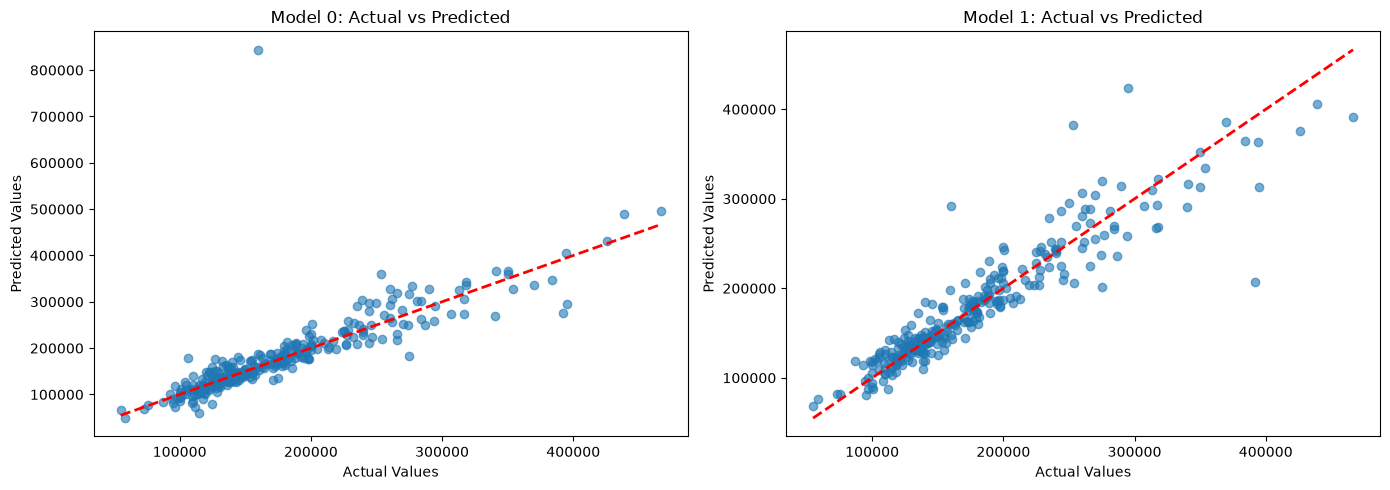

In [51]:
import math

n_models = len(models)
n_cols = 2
n_rows = math.ceil(n_models / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5 * n_rows))
axes = axes.flatten()

for i, model in enumerate(models):
    y_pred = model.predict(X_test)

    axes[i].scatter(y_test, y_pred, alpha=0.6)
    axes[i].plot(
        [y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        'r--', lw=2
    )
    axes[i].set_title(f"Model {i}: Actual vs Predicted")
    axes[i].set_xlabel("Actual Values")
    axes[i].set_ylabel("Predicted Values")

# Remove unused subplots
for j in range(len(models), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


In [52]:
test_df = pd.read_csv('https://raw.githubusercontent.com/bahaa0alsaeed/House-Price-Data-Base/refs/heads/main/test.csv')

X = test_df[all_cols]
y_pred = best_model.predict(X)
submission = pd.DataFrame({
    "Id": test_df["Id"],
    "SalePrice": y_pred
})

submission.to_csv("submission2.csv", index=False)

/home/bahaa/Documents/Python/.venv/lib64/python3.14/site-packages/sklearn/utils/validation.py:2820: UserWarning: X has feature names, but SimpleImputer was fitted without feature names
  warnings.warn(
/home/bahaa/Documents/Python/.venv/lib64/python3.14/site-packages/sklearn/utils/validation.py:2820: UserWarning: X has feature names, but SimpleImputer was fitted without feature names
  warnings.warn(
